In [1]:
import pandas as pd

df = pd.read_csv("data/reduced_world_real_estate_data.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Country              144961 non-null  object 
 1   Property_Type        144961 non-null  object 
 2   Height               144961 non-null  float64
 3   Price_and_Modernity  144961 non-null  float64
 4   Building_Age         144961 non-null  float64
 5   Interior_Amenities   144961 non-null  float64
 6   Total_Area           144961 non-null  float64
dtypes: float64(5), object(2)
memory usage: 7.7+ MB


In [3]:
df.describe(include='all')

,Country,Property_Type,Height,Price_and_Modernity,Building_Age,Interior_Amenities,Total_Area
count,144961,144961,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05
unique,27,4,NaN,NaN,NaN,NaN,NaN
top,Turkey,apartment,NaN,NaN,NaN,NaN,NaN
freq,25681,97212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2.509626e-17,-1.254813e-17,-6.274065e-18,-9.411097e-18,-1.666548e-18
std,NaN,NaN,1.407400e+00,1.311498e+00,1.168098e+00,1.034752e+00,1.000217e+00
min,NaN,NaN,-3.420469e+01,-1.284637e+01,-4.598057e+01,-1.413038e+02,-1.401653e+01
25%,NaN,NaN,-9.604729e-01,-5.198154e-01,-8.844700e-02,-4.115811e-01,-1.350424e-02
50%,NaN,NaN,-3.948849e-02,-3.418427e-02,2.358547e-01,-1.305813e-01,1.593640e-04
75%,NaN,NaN,6.117692e-01,4.667887e-01,4.587621e-01,2.273246e-01,1.335367e-02


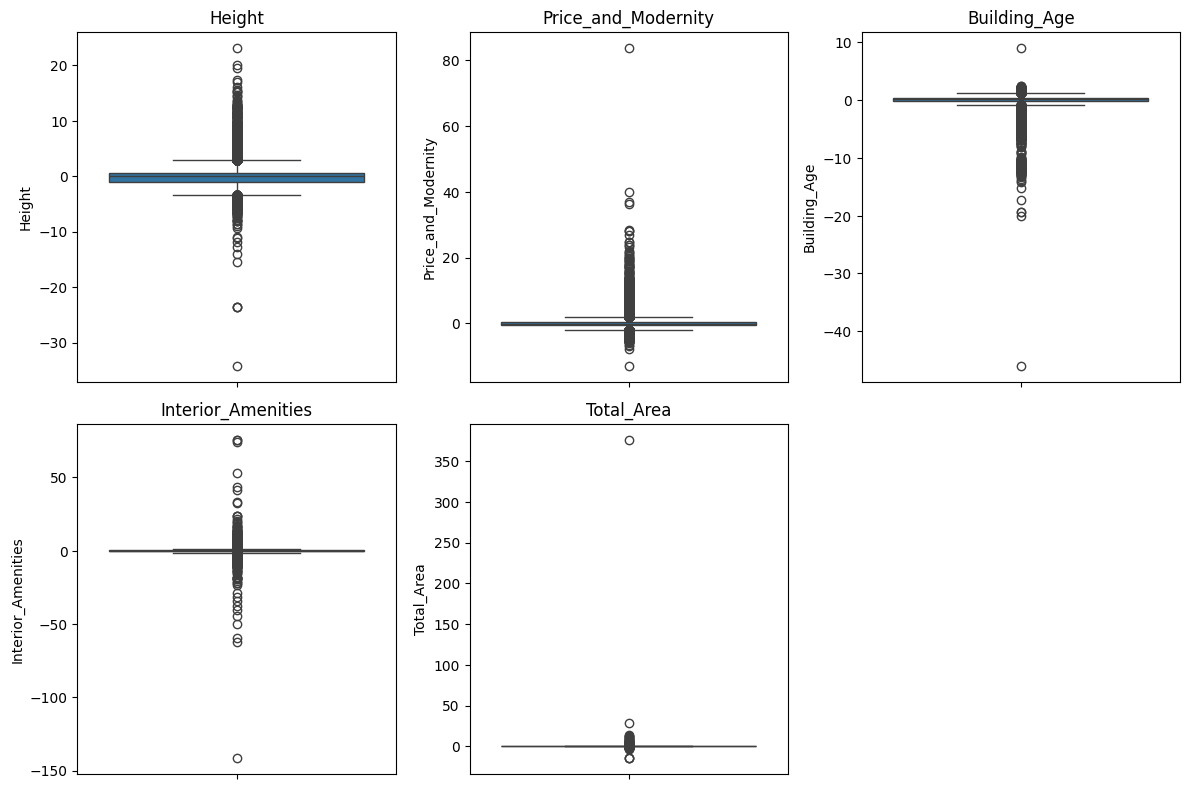

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Height', 'Price_and_Modernity', 'Building_Age', 'Interior_Amenities', 'Total_Area']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [5]:
from scipy import stats
import numpy as np

zscore_mask = np.zeros(len(df), dtype=bool)
zscore_info = {}

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > 3  
    zscore_info[col] = mask.sum()
    zscore_mask |= mask

df['is_outlier_zscore'] = zscore_mask
print("Z-Score Outliers (|z| > 3):")
print(f"Total: {df['is_outlier_zscore'].sum()} ({df['is_outlier_zscore'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in zscore_info.items():
    print(f"  {col}: {count}")

Z-Score Outliers (|z| > 3):
Total: 4864 (3.36%)

Outliers per PC:
  Height: 1875
  Price_and_Modernity: 2109
  Building_Age: 1310
  Interior_Amenities: 1004
  Total_Area: 39
